In [1]:
import pandas as pd
import datasets
from datasets import Image as Image_ds # change name because of similar PIL module
from datasets import Dataset
import os
import requests 
from PIL import Image
from tqdm import tqdm
import torch
from transformers import pipeline
import diffusers
from datasets import load_dataset

/Users/au672746/Library/CloudStorage/OneDrive-Aarhusuniversitet/CHC/art-multimodal-benchmark/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# load dataset
# load image data
ds = load_dataset("louisebrix/smk_canon_paintings", split="train") # all the data is in the 'train' split

In [3]:
from diffusers import AutoencoderKL

# 1. Load the autoencoder model which will be used to decode the latents into image space. 
vae = AutoencoderKL.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="vae")

In [4]:
import numpy as np
from torchvision import transforms
# Convert PIL image to tensor and add batch dimension
image = ds[0]['image']  # likely a PIL image

preprocess = transforms.Compose([
    transforms.ToTensor(),                     # Converts to (C, H, W) and normalizes to [0,1]
    transforms.Resize((512, 512))# Resize to match model input (optional, adjust as needed)
])

tensor = preprocess(image).unsqueeze(0)        # (1, C, H, W) — adds batch dimension

# Move to same device as the model
tensor = tensor.to(vae.device)

# Run through VAE
output = vae.encoder(tensor)

In [5]:
output.detach().numpy().shape

(1, 8, 64, 64)

In [6]:
pooling = torch.mean(output, dim=(2, 3))
pooling.detach().numpy().shape

(1, 8)

#### Pooling and Flattening Encoder output 

In [7]:
import torch
import torch.nn as nn
from torchvision import transforms

# Example stats for standardization (ImageNet mean/std)
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Compose preprocessing with standardization
preprocess = transforms.Compose([
    transforms.Resize((512, 512)),             # Resize first (optional, adjust as needed)
    transforms.ToTensor(),                      # Convert PIL image to tensor (C, H, W) normalized to [0,1]
    transforms.Normalize(mean=mean, std=std)   # Standardize pixels per channel
])

# Load and preprocess image (PIL)
image = ds[0]['image']  # Your input PIL image

tensor = preprocess(image).unsqueeze(0)       # Add batch dimension -> (1, C, H, W)

# Move tensor to same device as your model
tensor = tensor.to(vae.device)

# Run through encoder to get features
features = vae.encoder(tensor)  # Assuming output shape: (1, 8, 64, 64) or similar

# Adaptive average pooling to reduce spatial dims to 16x16
adaptive_pool = nn.AdaptiveAvgPool2d((16, 16))
pooled_features = adaptive_pool(features)    # (1, 8, 16, 16)

# Flatten to get a feature vector of size 8*16*16 = 2048
flattened = pooled_features.view(pooled_features.size(0), -1)  # (1, 2048)

print(flattened.shape)  # Should print: torch.Size([1, 2048])

torch.Size([1, 2048])


In [5]:
def test_diffusion_encoder(img, vae):
    # Example stats for standardization (ImageNet mean/std)
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]

    # Compose preprocessing with standardization
    preprocess = transforms.Compose([
        transforms.Resize((512, 512)),             # Resize first (optional, adjust as needed)
        transforms.ToTensor(),                      # Convert PIL image to tensor (C, H, W) normalized to [0,1]
        transforms.Normalize(mean=mean, std=std)   # Standardize pixels per channel
    ])

    tensor = preprocess(img).unsqueeze(0)       # Add batch dimension -> (1, C, H, W)

    # Move tensor to same device as your model
    tensor = tensor.to(vae.device)

    # Run through encoder to get features
    features = vae.encoder(tensor)  # Assuming output shape: (1, 8, 64, 64) or similar

    # Adaptive average pooling to reduce spatial dims to 16x16
    adaptive_pool = nn.AdaptiveAvgPool2d((16, 16))
    pooled_features = adaptive_pool(features)    # (1, 8, 16, 16)

    # Flatten to get a feature vector of size 8*16*16 = 2048
    flattened = pooled_features.view(pooled_features.size(0), -1)  # (1, 2048)

    return flattened 

In [10]:
subset = ds.select(range(30))

In [7]:
# initialize empty list
embeddings = []

# loop over each image in the dataset and extract feature embeddings
for i in tqdm(range(len(subset)), desc="Extracting features from images"):
    try:
        img = subset[i]['image']
        feature = test_diffusion_encoder(img, vae)
        embeddings.append(feature)
    
    except Exception as e:
        print(f"Error processing image {i}: {e}")


Extracting features from images:  27%|██▋       | 8/30 [00:38<01:41,  4.62s/it]

: 

In [5]:
features = np.load(os.path.join('data', 'features.npy'))

In [6]:
features.shape

(30, 1, 2048)

In [7]:
embeddings = features.squeeze(axis=1)

In [8]:
embedding_list = [embeddings[i] for i in range(embeddings.shape[0])]

In [11]:
subset = subset.add_column('embedding_new', embedding_list)

In [17]:
type(subset[0]['embedding_new'])

list

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from umap import UMAP
from sklearn.decomposition import PCA

In [20]:
# inspect features with UMAP plot
def umap_plot(ax:plt.Axes, df:pd.DataFrame, ds:Dataset, embedding:str, n_components:int = 10):

    '''
    Plot all paintings with UMAP
    
    Parameters:
        - ax: Plt axes to plot on
        - df: Dataframe with embeddings
        - ds: Dataset with color images
        - embedding: name of embedding col in df
        - filename: Name to save the plot as
        - n_components: Number of PCA components for initial dimensionality reduction
    '''
    def getImage(img):
        return OffsetImage(np.array(img), zoom=.02)

    embeddings_array = np.array(df[embedding], dtype=np.float32)

    # reduce dimensionality
    pca = PCA(n_components=n_components)
    pca_results = pca.fit_transform(embeddings_array)

    # fit UMAP on PCA-reduced data
    X = np.array(pca_results)
    umap_fitted = UMAP(n_components=2, random_state=42).fit_transform(X)
    df_umap = pd.DataFrame(umap_fitted, columns=["umap1", "umap2"])
    
    ax.scatter(df_umap['umap1'], df_umap['umap2'], color='white') # make invisible

    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.axis("equal")
    ax.set_axis_off()

    for index, row in df_umap.iterrows():
        # add images to plot
        ab = AnnotationBbox(getImage(ds[index]['image']), (row["umap1"], row["umap2"]), frameon=False)
        ax.add_artist(ab)

    plt.savefig(f'umap_n{n_components}.pdf', format='pdf', dpi=300)

    np.seterr(divide='ignore', invalid='ignore')

Creating UMAP plot...


/Users/au672746/Library/CloudStorage/OneDrive-Aarhusuniversitet/CHC/art-multimodal-benchmark/env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


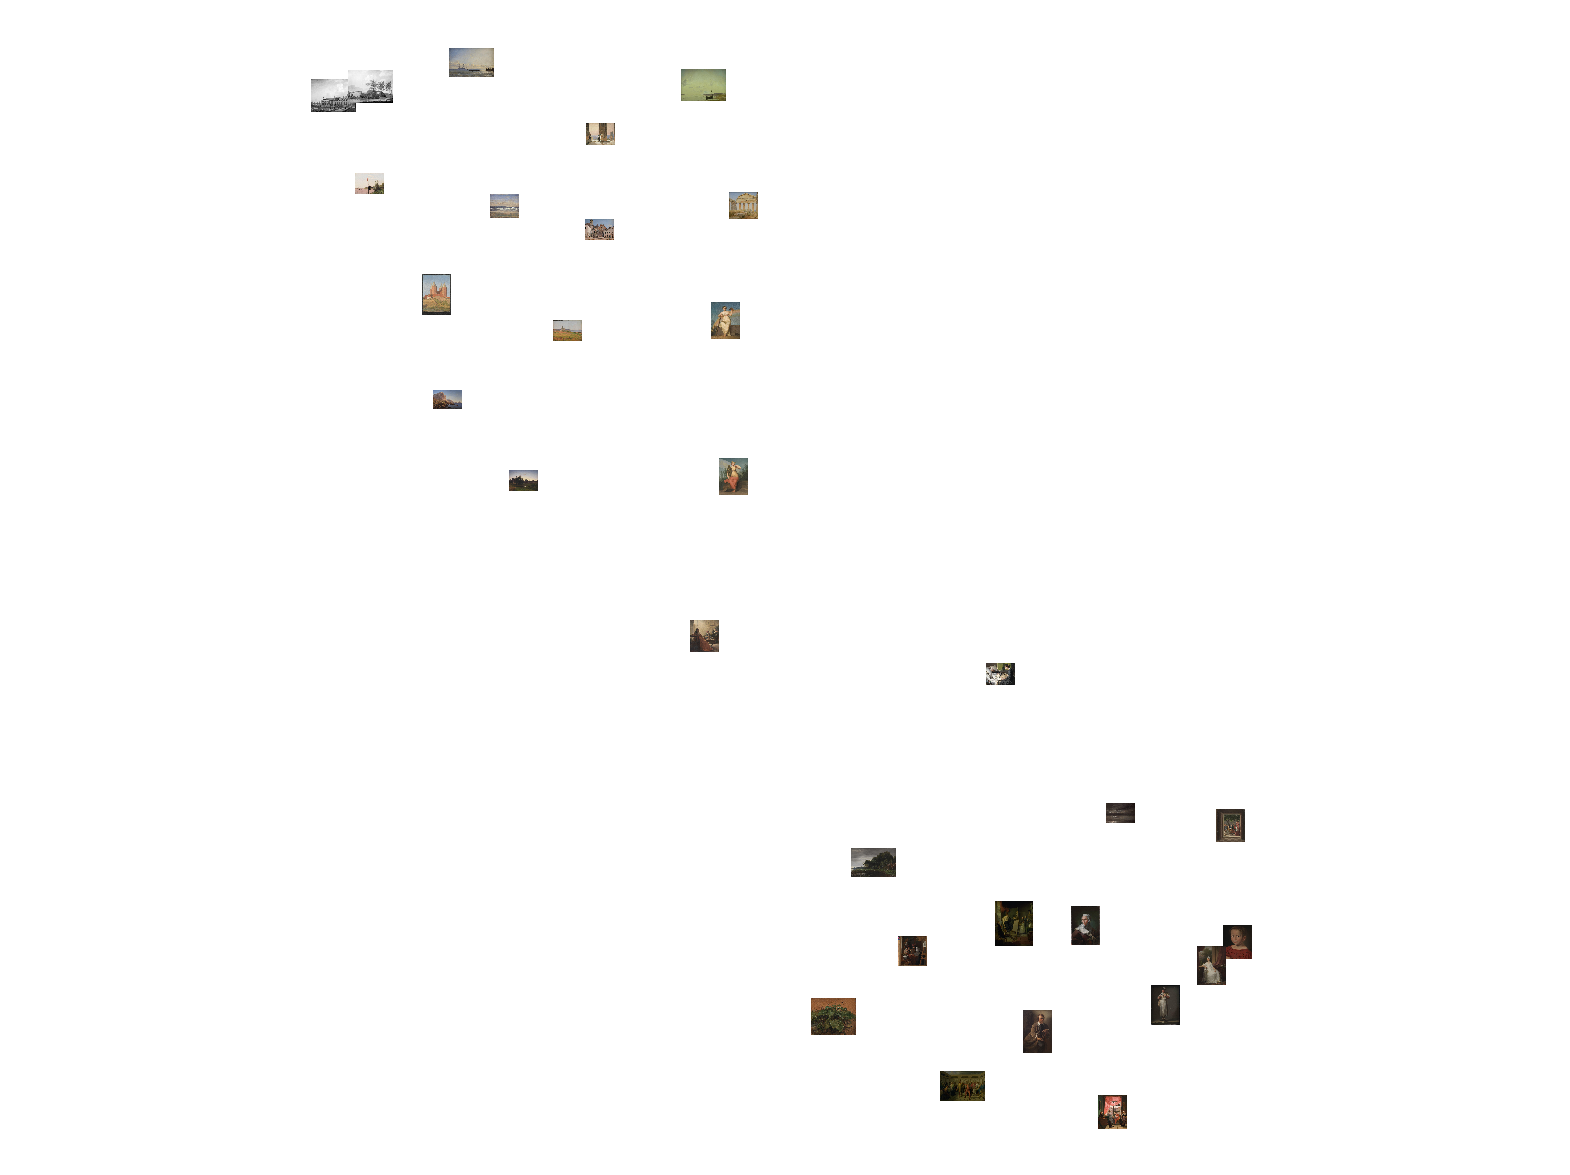

In [21]:
# plot and save color UMAP
fig, axs = plt.subplots(1, 1, figsize=(20, 15))
print('Creating UMAP plot...')
umap_plot(axs, subset, subset, 'embedding_new')

In [22]:
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_distances

In [23]:
def find_neighbors(feature_list, target_image):
    # initialize K-nearest neighbors algorithm
    neighbors = NearestNeighbors(n_neighbors=10, 
                            algorithm='brute',
                            metric='cosine').fit(feature_list)
    
    # save the indices and distances of the neighbors to the target image
    distances, indices = neighbors.kneighbors([feature_list[target_image]])

    # initialize empty lists
    idxs = []
    dist = []
    
        # save the 5 closest images' indices and distances
    for i in range(1,10):
        idxs.append(indices[0][i])
        dist.append(distances[0][i])

    # create dataframe
    data = pd.DataFrame({
                        "distance_score" : pd.Series(dist),
                        'index': pd.Series(idxs)})
    
    print(data['index'])
    
    # return filenames as a pandas series to be used in the plotting function
    return data
def show_plot(names, target_image, dataset):
    
    # arrange plots
    f, axarr = plt.subplots(3, 3,figsize=(8, 6))
    
    
    # print target image
    axarr[0,0].imshow(dataset[target_image]['image'])
    axarr[0, 0].set_title('Target Image')

    # plot 5 most similar next to it
    axarr[0,1].imshow(dataset[names[0]]['image'])
    axarr[0,2].imshow(dataset[names[1]]['image'])
    axarr[1,0].imshow(dataset[names[2]]['image'])
    axarr[1,1].imshow(dataset[names[3]]['image'])
    axarr[1,2].imshow(dataset[names[4]]['image'])
    axarr[2,0].imshow(dataset[names[5]]['image'])
    axarr[2,1].imshow(dataset[names[6]]['image'])
    axarr[2,2].imshow(dataset[names[7]]['image'])
    
    # remove axes from plot
    #for ax in f.axes:
      #  ax.axison = False

    for ax in f.axes:
        ax.axis('off')
        ax.set_aspect('equal')

    f.subplots_adjust(wspace=0.01, hspace=0.01)
        
    #plt.show()
    
    #plt.subplots_adjust(wspace=0, hspace=0)
    #plt.subplots_adjust(left=0, bottom=0, right=1, top=0, wspace=0, hspace=0)
    #plt.savefig(os.path.join('out', 'plots', plot_name))
    plt.show()
  
def plot_neighbors(feature_list, target_image, dataset):

    # find closest images and save in a df
    data = find_neighbors(feature_list, target_image)

    # save the indices of the closest images
    indices = data['index'].tolist()

    # plot them
    show_plot(indices, target_image, dataset)

0    26
1    24
2     5
3    15
4    12
5     6
6    29
7     8
8    13
Name: index, dtype: int64


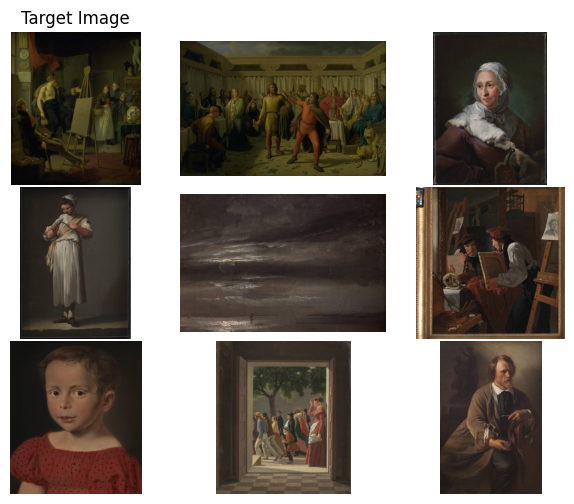

In [29]:
feature_list = np.array(subset['embedding_new'], dtype=np.float32)
plot_neighbors(feature_list, 25, subset) # choose random image as target image